# L07 · Neural Networks and Backpropagation

*Companion notebook for Lecture 7 — Neural Networks and Backpropagation (CS184A/284A, AI in Biology and Medicine).*

**Learning objectives**

1. Write the forward pass of a 2-layer MLP in NumPy, in the course notation
   $\mathbf z^{(\ell)} = \mathbf W^{(\ell)}\mathbf h^{(\ell-1)} + \mathbf b^{(\ell)}$, $\mathbf h^{(\ell)} = g(\mathbf z^{(\ell)})$, with every shape checked.
2. Write backpropagation by hand and verify it numerically (finite differences) and against PyTorch autograd.
3. Train with mini-batch SGD and see how the decision boundary changes with the hidden width (two moons, XOR).
4. Compare an MLP with logistic regression (Lecture 5) on breast-biopsy data, with cross-validation and a held-out test set.

Notation: $n$ samples, $d$ features, $\mathbf X\in\mathbb R^{n\times d}$ with samples as rows; $\mathbf W^{(\ell)}\in\mathbb R^{d_\ell\times d_{\ell-1}}$
(one row per unit, as in PyTorch `nn.Linear`); loss $\mathcal L$, learning rate $\eta$, L2 strength $\lambda$; $y = 1$ = malignant.
All experiments use the data, splits, seeds and settings of the lecture, so the printed numbers match the slides.

In [1]:
import sys, pathlib, time
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # course_utils.py lives in applications/
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, load_breast_cancer
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from course_utils import seed_everything, plot_style, PALETTE

rng = seed_everything(0)
plot_style()
C0, C1 = PALETTE[0], PALETTE[5]                  # class 0 (benign / blue), class 1 (malignant / orange), as on the slides
T0 = time.time()

## 1. Datasets

**Toy data (synthetic, generated here).** *Two moons* (`sklearn.datasets.make_moons`): two interleaved half-circles with
noise; 2 features, 2 classes; no straight line separates them. *XOR*: four Gaussian clouds at the corners of the unit square,
class 1 when exactly one coordinate is 1 — the problem a single perceptron cannot solve.

**Breast biopsies.** Wisconsin Diagnostic Breast Cancer (WDBC; Street, Wolberg & Mangasarian 1993), shipped with scikit-learn
(UCI Machine Learning Repository, CC BY 4.0).
- **What is measured**: a fine-needle aspirate (FNA) of a breast mass is imaged; the cell nuclei are outlined and summarized.
- **One sample** = one biopsy ($n = 569$). **Input**: $d = 30$ nuclear features (mean, standard error and "worst" value of radius,
  texture, perimeter, area, smoothness, compactness, concavity, concave points, symmetry, fractal dimension).
- **Target**: malignant ($y = 1$) vs benign. scikit-learn codes benign as 1, so we use `y = 1 - target`.
- **Why it matters**: an automated second reader for cytology; both kinds of error are costly.

In [2]:
def make_xor(n_per=50, sd=0.15, rng=rng):
    centers = [(0, 0, 0), (1, 1, 0), (0, 1, 1), (1, 0, 1)]   # (x1, x2, class)
    X = np.vstack([rng.normal((a, b), sd, (n_per, 2)) for a, b, _ in centers])
    y = np.repeat([c for *_, c in centers], n_per)
    return X - 0.5, y

Xm, ym = make_moons(400, noise=0.25, random_state=1)        # the lecture's width experiment
Xx, yx = make_xor()
bc = load_breast_cancer()
Xb, yb = bc.data, 1 - bc.target                               # y = 1: malignant
print(f"moons {Xm.shape}, XOR {Xx.shape}, WDBC {Xb.shape}: {yb.sum()} malignant / {len(yb) - yb.sum()} benign")

moons (400, 2), XOR (200, 2), WDBC (569, 30): 212 malignant / 357 benign


## 2. Exploration

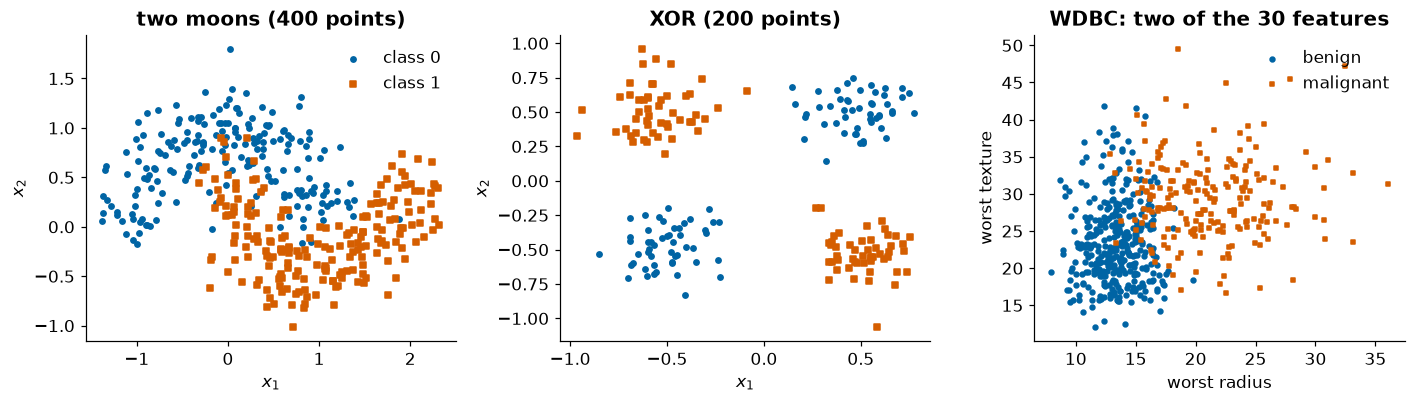

In [3]:
fig, axs = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, (X, y, name) in zip(axs[:2], [(Xm, ym, "two moons (400 points)"), (Xx, yx, "XOR (200 points)")]):
    ax.scatter(*X[y == 0].T, s=12, color=C0, label="class 0")
    ax.scatter(*X[y == 1].T, s=12, color=C1, marker="s", label="class 1")
    ax.set_title(name); ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
axs[0].legend()
names = list(bc.feature_names)
j1, j2 = names.index("worst radius"), names.index("worst texture")
axs[2].scatter(Xb[yb == 0, j1], Xb[yb == 0, j2], s=10, color=C0, label="benign")
axs[2].scatter(Xb[yb == 1, j1], Xb[yb == 1, j2], s=10, color=C1, marker="s", label="malignant")
axs[2].set_xlabel("worst radius"); axs[2].set_ylabel("worst texture"); axs[2].set_title("WDBC: two of the 30 features")
axs[2].legend(); plt.tight_layout(); plt.show()

## 3. Model: the forward pass
A 2-layer MLP $d_0 \to d_1 \to d_2$ with activation $g$ (tanh or ReLU) in the hidden layer:

$$\mathbf z^{(1)} = \mathbf W^{(1)}\mathbf x + \mathbf b^{(1)},\quad \mathbf h^{(1)} = g(\mathbf z^{(1)}),\quad
\mathbf z^{(2)} = \mathbf W^{(2)}\mathbf h^{(1)} + \mathbf b^{(2)},\quad \hat{\mathbf y} = \mathrm{softmax}(\mathbf z^{(2)})\ \text{or}\ \sigma(z^{(2)})\ (d_2 = 1).$$

The loss is the average cross-entropy (binary cross-entropy when $d_2 = 1$) plus $\lambda(\|\mathbf W^{(1)}\|^2 + \|\mathbf W^{(2)}\|^2)$.
In code a mini-batch is processed at once, samples as rows: $\mathbf H^{(1)} = g(\mathbf X\mathbf W^{(1)\top} + \mathbf 1\mathbf b^{(1)\top})$.

**Backward pass.** For softmax + cross-entropy *and* for sigmoid + binary cross-entropy the output error is the same,
$\boldsymbol\delta^{(2)} = \partial\ell/\partial\mathbf z^{(2)} = \hat{\mathbf y} - \mathbf y$ (Lecture 5). Then
$\partial\mathcal L/\partial\mathbf W^{(2)} = \boldsymbol\delta^{(2)}\mathbf h^{(1)\top}$,
$\boldsymbol\delta^{(1)} = (\mathbf W^{(2)\top}\boldsymbol\delta^{(2)})\odot g'(\mathbf z^{(1)})$,
$\partial\mathcal L/\partial\mathbf W^{(1)} = \boldsymbol\delta^{(1)}\mathbf x^\top$. Batched, `gW2 = D2.T @ H1` sums the outer products over the batch.

In [4]:
ACTS = {  # name: (g, g'(z, h)) — g' may use the stored activation h = g(z)
    "tanh": (np.tanh, lambda z, h: 1 - h ** 2),
    "relu": (lambda z: np.maximum(z, 0), lambda z, h: (z > 0).astype(float)),
}

def softmax(Z):
    Z = Z - Z.max(axis=1, keepdims=True)           # subtract the row max for numerical stability
    E = np.exp(Z)
    return E / E.sum(axis=1, keepdims=True)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

class MLP:
    """d0 -> d1 -> d2 network. d2 > 1: softmax + cross-entropy; d2 = 1: sigmoid + binary cross-entropy."""

    def __init__(self, d0, d1, d2, act="tanh", rng=None):
        r = np.random.default_rng(0) if rng is None else rng
        self.W1 = r.normal(0, 1 / np.sqrt(d0), (d1, d0)); self.b1 = np.zeros(d1)   # W1: (d1, d0), scale 1/sqrt(d0)
        self.W2 = r.normal(0, 1 / np.sqrt(d1), (d2, d1)); self.b2 = np.zeros(d2)   # W2: (d2, d1)
        self.g, self.gprime = ACTS[act]

    def params(self):
        return [self.W1, self.b1, self.W2, self.b2]

    def forward(self, X):
        Z1 = X @ self.W1.T + self.b1                   # (n, d1)
        H1 = self.g(Z1)                                # (n, d1)
        Z2 = H1 @ self.W2.T + self.b2                  # (n, d2)
        P = softmax(Z2) if Z2.shape[1] > 1 else sigmoid(Z2)   # (n, d2)
        self.cache = (X, Z1, H1)                       # stored for the backward pass
        return P

    def loss(self, X, Y, lam=0.0):                     # Y: one-hot (n, d2), or (n, 1) of 0/1 when d2 = 1
        P = self.forward(X)
        if P.shape[1] > 1:
            ce = -np.mean(np.sum(Y * np.log(P + 1e-12), axis=1))
        else:
            ce = -np.mean(Y * np.log(P + 1e-12) + (1 - Y) * np.log(1 - P + 1e-12))
        return ce + lam * (np.sum(self.W1 ** 2) + np.sum(self.W2 ** 2))

    def backward(self, P, Y, lam=0.0):
        X, Z1, H1 = self.cache
        n = len(X)
        D2 = (P - Y) / n                               # delta^(2) = yhat - y, one row per sample (averaged), (n, d2)
        gW2 = D2.T @ H1 + 2 * lam * self.W2            # (d2, d1)
        gb2 = D2.sum(axis=0)                           # (d2,)
        D1 = (D2 @ self.W2) * self.gprime(Z1, H1)      # delta^(1) = (W2^T delta^(2)) * g'(z^(1)), (n, d1)
        gW1 = D1.T @ X + 2 * lam * self.W1             # (d1, d0)
        gb1 = D1.sum(axis=0)                           # (d1,)
        return [gW1, gb1, gW2, gb2]

    def predict(self, X):
        P = self.forward(X)
        return P.argmax(axis=1) if P.shape[1] > 1 else (P[:, 0] > 0.5).astype(int)

    def n_params(self):
        return sum(p.size for p in self.params())

net = MLP(2, 8, 2)
P = net.forward(Xm[:5])
print("output probabilities for 5 samples:\n", P.round(3))
print("rows sum to 1:", np.allclose(P.sum(1), 1))
print("shapes:", {k: v.shape for k, v in zip(["W1", "b1", "W2", "b2"], net.params())}, f"-> {net.n_params()} parameters")
big = MLP(30, 16, 1, act="relu")
print("biopsy network 30 -> 16 -> 1:", {k: v.shape for k, v in zip(["W1", "b1", "W2", "b2"], big.params())},
      f"-> {big.n_params()} parameters (16·30 + 16 + 1·16 + 1; logistic regression has 31)")

output probabilities for 5 samples:
 [[0.384 0.616]
 [0.621 0.379]
 [0.418 0.582]
 [0.417 0.583]
 [0.548 0.452]]
rows sum to 1: True
shapes: {'W1': (8, 2), 'b1': (8,), 'W2': (2, 8), 'b2': (2,)} -> 42 parameters
biopsy network 30 -> 16 -> 1: {'W1': (16, 30), 'b1': (16,), 'W2': (1, 16), 'b2': (1,)} -> 513 parameters (16·30 + 16 + 1·16 + 1; logistic regression has 31)


### Worked example from the slides: one hidden unit
$x = 1.5$, $y = 1$, $w_1 = 0.8$, $b_1 = -0.5$, $w_2 = -1.2$, $b_2 = 0.3$; $h = \tanh(w_1x + b_1)$, $\hat y = \sigma(w_2h + b_2)$,
binary cross-entropy. The `MLP` class with $d_0 = d_1 = d_2 = 1$ is exactly this network.

In [5]:
tiny = MLP(1, 1, 1)
tiny.W1[:] = 0.8; tiny.b1[:] = -0.5; tiny.W2[:] = -1.2; tiny.b2[:] = 0.3
xt, yt = np.array([[1.5]]), np.array([[1.0]])
P = tiny.forward(xt)
_, Z1, H1 = tiny.cache
print(f"forward: z1 = {Z1[0, 0]:.3f}, h = {H1[0, 0]:.3f}, yhat = {P[0, 0]:.3f}, loss = {tiny.loss(xt, yt):.3f}")
gw1, gb1, gw2, gb2 = (g.item() for g in tiny.backward(P, yt))
print(f"backward: dL/dw1 = {gw1:.6f}, dL/db1 = {gb1:.6f}, dL/dw2 = {gw2:.6f}, dL/db2 = {gb2:.6f}")

forward: z1 = 0.700, h = 0.604, yhat = 0.395, loss = 0.928
backward: dL/dw1 = 0.690931, dL/db1 = 0.460620, dL/dw2 = -0.365483, dL/db2 = -0.604737


## 4. Gradient check
Compare the backprop gradient $g$ with a centered finite difference
$\tilde g_j = [\mathcal L(\theta + \epsilon\mathbf e_j) - \mathcal L(\theta - \epsilon\mathbf e_j)] / 2\epsilon$ for **every** parameter
($\epsilon = 10^{-5}$, float64) and report the relative error $\|g - \tilde g\| / (\|g\| + \|\tilde g\|)$.
Rule of thumb: $\lesssim 10^{-7}$ good; $\gtrsim 10^{-3}$ a bug. Two loss evaluations per parameter — for testing only.

Setting of the slide: NumPy MLP 2 → 8 → 2 (tanh) on 200 two-moons points (`noise=0.2, random_state=0`), weights drawn from
`default_rng(0)`, no L2 penalty.

In [6]:
def grad_check(net, X, Y, lam=0.0, eps=1e-5):
    g = net.backward(net.forward(X), Y, lam)
    num = []
    for Pm in net.params():
        G = np.zeros_like(Pm)
        for idx in np.ndindex(Pm.shape):
            old = Pm[idx]
            Pm[idx] = old + eps; lp = net.loss(X, Y, lam)
            Pm[idx] = old - eps; lm = net.loss(X, Y, lam)
            Pm[idx] = old
            G[idx] = (lp - lm) / (2 * eps)
        num.append(G)
    a = np.concatenate([x.ravel() for x in g]); b = np.concatenate([x.ravel() for x in num])
    return np.linalg.norm(a - b) / (np.linalg.norm(a) + np.linalg.norm(b))

rng_chk = np.random.default_rng(0)
Xc, yc = make_moons(200, noise=0.2, random_state=0)
Yc = np.eye(2)[yc]
net_chk = MLP(2, 8, 2, act="tanh", rng=rng_chk)
print(f"2 -> 8 -> 2 tanh, {net_chk.n_params()} parameters: relative error = {grad_check(net_chk, Xc, Yc):.1e}")
for act in ["tanh", "relu"]:
    rel = grad_check(MLP(2, 8, 2, act=act, rng=np.random.default_rng(3)), Xc, Yc, lam=1e-3)
    print(f"  {act}, with L2 penalty lambda = 1e-3: relative error = {rel:.1e}")
rel = grad_check(MLP(30, 16, 1, act="relu", rng=np.random.default_rng(0)),
                 StandardScaler().fit_transform(Xb[:100]), yb[:100, None].astype(float), lam=1e-3)
print(f"  30 -> 16 -> 1 relu + sigmoid output (513 parameters) on 100 biopsies: relative error = {rel:.1e}")

2 -> 8 -> 2 tanh, 42 parameters: relative error = 3.6e-11
  tanh, with L2 penalty lambda = 1e-3: relative error = 2.1e-11
  relu, with L2 penalty lambda = 1e-3: relative error = 2.4e-11


  30 -> 16 -> 1 relu + sigmoid output (513 parameters) on 100 biopsies: relative error = 9.9e-11


**A deliberate bug.** Drop the $g'(\mathbf z^{(1)})$ factor from the backward pass and the check fails loudly:

In [7]:
class BuggyMLP(MLP):
    def backward(self, P, Y, lam=0.0):
        X, Z1, H1 = self.cache
        D2 = (P - Y) / len(X)
        D1 = D2 @ self.W2                              # BUG: missing * g'(Z1)
        return [D1.T @ X + 2 * lam * self.W1, D1.sum(0), D2.T @ H1 + 2 * lam * self.W2, D2.sum(0)]

print(f"buggy backward: relative error = {grad_check(BuggyMLP(2, 8, 2, rng=np.random.default_rng(0)), Xc, Yc):.1e}")

buggy backward: relative error = 1.3e-01


### Cross-check with PyTorch autograd
PyTorch computes the same gradients by reverse-mode automatic differentiation. We copy the weights of the 30 → 16 → 1 biopsy
network into float64 tensors, compute the same loss, call `backward()`, and compare.

In [8]:
import torch

net = MLP(30, 16, 1, act="relu", rng=np.random.default_rng(1))
Xs = StandardScaler().fit_transform(Xb)[:64]
Ys = yb[:64, None].astype(float)
lam = 1e-3
ours = net.backward(net.forward(Xs), Ys, lam)

T = [torch.tensor(p, dtype=torch.float64, requires_grad=True) for p in net.params()]
W1, b1, W2, b2 = T
Xt, Yt = torch.tensor(Xs), torch.tensor(Ys)
z2 = torch.relu(Xt @ W1.T + b1) @ W2.T + b2
loss = torch.nn.functional.binary_cross_entropy_with_logits(z2, Yt) + lam * ((W1 ** 2).sum() + (W2 ** 2).sum())
loss.backward()
print(f"loss: ours {net.loss(Xs, Ys, lam):.6f} | torch {loss.item():.6f}")
for name, g, t in zip(["W1", "b1", "W2", "b2"], ours, T):
    print(f"{name} {tuple(g.shape)}: max |ours - autograd| = {np.abs(g - t.grad.numpy()).max():.1e}")

loss: ours 0.696476 | torch 0.696476
W1 (16, 30): max |ours - autograd| = 1.4e-17
b1 (16,): max |ours - autograd| = 1.4e-17
W2 (1, 16): max |ours - autograd| = 1.1e-16
b2 (1,): max |ours - autograd| = 0.0e+00


## 5. Training with mini-batch SGD
Each epoch: shuffle, split into mini-batches $B$, forward, backward, update $\theta \leftarrow \theta - \eta\nabla_\theta\mathcal L_B$.
Slide setting: 2 → 8 → 2 (tanh) on the 200 moons of the gradient check, $\eta = 0.5$, $|B| = 20$, 200 epochs, weights from
`default_rng(1)`; the shuffles continue the `default_rng(0)` stream used above.

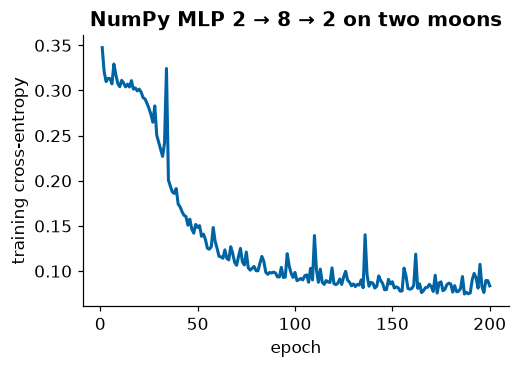

final training loss 0.084, training accuracy 0.97


In [9]:
def train(net, X, Y, eta=0.5, epochs=200, batch=20, lam=0.0, rng=None):
    r = np.random.default_rng(0) if rng is None else rng
    hist = []
    for ep in range(epochs):
        idx = r.permutation(len(X))
        for s in range(0, len(X), batch):
            b = idx[s:s + batch]
            grads = net.backward(net.forward(X[b]), Y[b], lam)
            for Pm, G in zip(net.params(), grads):
                Pm -= eta * G                          # in-place update
        hist.append(net.loss(X, Y, lam))
    return hist

net = MLP(2, 8, 2, act="tanh", rng=np.random.default_rng(1))
hist = train(net, Xc, Yc, eta=0.5, epochs=200, batch=20, rng=rng_chk)
plt.figure(figsize=(5, 3.2)); plt.plot(np.arange(1, 201), hist, color=C0, lw=2)
plt.xlabel("epoch"); plt.ylabel("training cross-entropy"); plt.title("NumPy MLP 2 → 8 → 2 on two moons"); plt.show()
print(f"final training loss {hist[-1]:.3f}, training accuracy {np.mean(net.predict(Xc) == yc):.2f}")

## 6. Decision boundary vs hidden width
The lecture's width experiment: 400 moons (`noise=0.25, random_state=1`), half for training and half for testing
(`random_state=0`), tanh hidden layer with 1, 2, 4 and 32 units. One unit gives a (squashed) linear boundary; a few units bend it;
many units can start to follow noise. We train our NumPy MLP with SGD, and do the same on XOR.

NumPy MLP  moons width  1: train 0.865  test 0.855


NumPy MLP  moons width  2: train 0.870  test 0.845


NumPy MLP  moons width  4: train 0.935  test 0.920


NumPy MLP  moons width 32: train 0.960  test 0.900


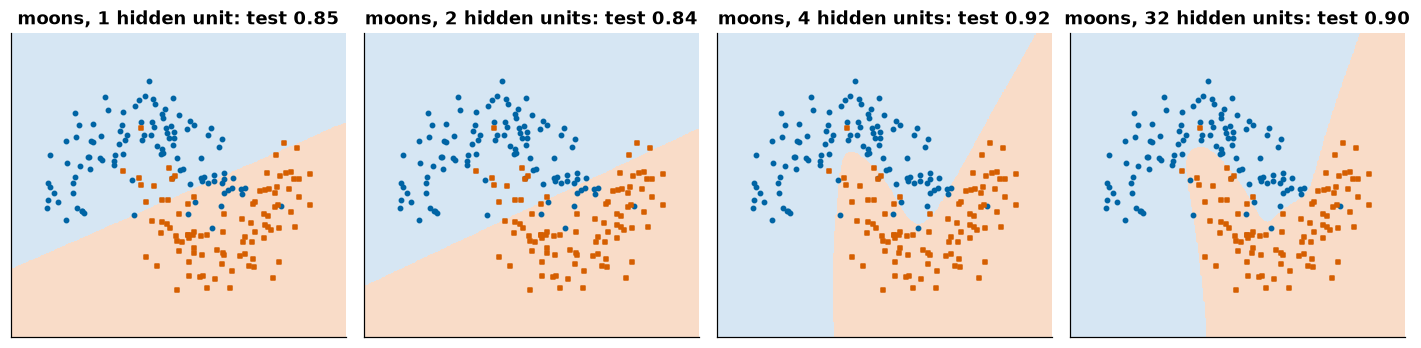

NumPy MLP  XOR   width  1: train 0.750  test 0.740


NumPy MLP  XOR   width  2: train 1.000  test 0.960


NumPy MLP  XOR   width  4: train 1.000  test 0.990


NumPy MLP  XOR   width 32: train 1.000  test 1.000


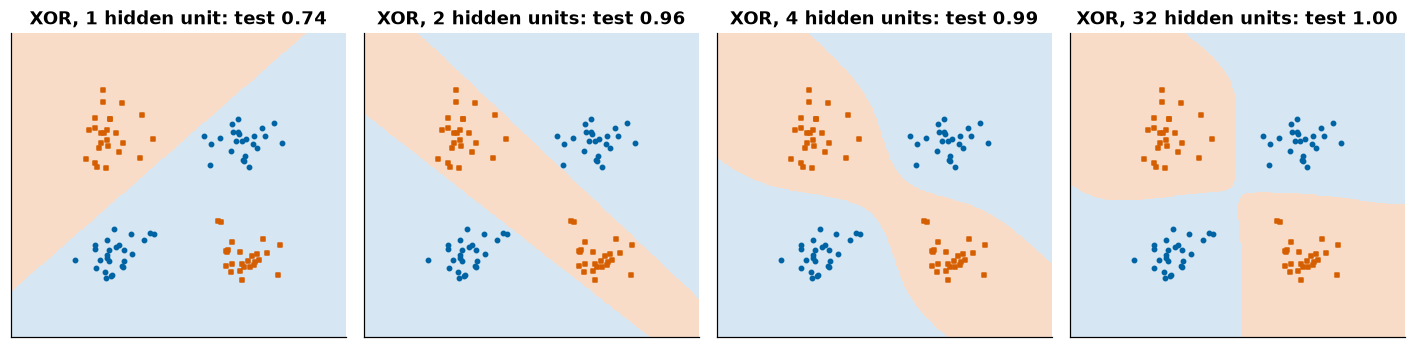

In [10]:
def plot_boundary(ax, predict, X, y, title):
    gx, gy = np.meshgrid(np.linspace(X[:, 0].min() - .5, X[:, 0].max() + .5, 250),
                         np.linspace(X[:, 1].min() - .5, X[:, 1].max() + .5, 250))
    Z = predict(np.c_[gx.ravel(), gy.ravel()]).reshape(gx.shape)
    ax.contourf(gx, gy, Z, levels=[-.5, .5, 1.5], colors=["#D6E6F3", "#F9DCC8"])
    ax.scatter(*X[y == 0].T, s=8, color=C0); ax.scatter(*X[y == 1].T, s=8, color=C1, marker="s")
    ax.set_title(title, fontsize=12); ax.set_xticks([]); ax.set_yticks([])

widths = [1, 2, 4, 32]
Xm_tr, Xm_te, ym_tr, ym_te = train_test_split(Xm, ym, test_size=0.5, random_state=0)
Xx_tr, Xx_te, yx_tr, yx_te = train_test_split(Xx, yx, test_size=0.5, random_state=0, stratify=yx)
for A, B, ya, yb_, name in [(Xm_tr, Xm_te, ym_tr, ym_te, "moons"), (Xx_tr, Xx_te, yx_tr, yx_te, "XOR")]:
    fig, axs = plt.subplots(1, len(widths), figsize=(13, 3.3))
    for ax, k in zip(axs, widths):
        net = MLP(2, k, 2, act="tanh", rng=np.random.default_rng(0))
        train(net, A, np.eye(2)[ya], eta=0.5, epochs=400, batch=20, rng=np.random.default_rng(0))
        tr, te = np.mean(net.predict(A) == ya), np.mean(net.predict(B) == yb_)
        print(f"NumPy MLP  {name:5s} width {k:2d}: train {tr:.3f}  test {te:.3f}")
        plot_boundary(ax, net.predict, A, ya, f"{name}, {k} hidden unit{'s' if k > 1 else ''}: test {te:.2f}")
    plt.tight_layout(); plt.show()

**The slide's numbers.** The deck's figure was trained with scikit-learn's `MLPClassifier` (lbfgs, L2 $\alpha = 10^{-4}$,
`random_state=0`) on the same moons split; the "no nonlinearity" slide used a 2 → 8 → 8 → 8 → 1 network (lbfgs, $\alpha = 0.1$).
The non-convex loss means a different optimizer (SGD above vs lbfgs here) finds a different solution, so our NumPy numbers are
close but not identical (deck: widths 1/2/4/32 → test 0.85 / 0.845 / 0.905 / 0.86; logistic regression 0.845; deep network
without activations 0.85 vs tanh 0.885).

In [11]:
for k in widths:
    m = MLPClassifier(hidden_layer_sizes=(k,), activation="tanh", solver="lbfgs", max_iter=5000, alpha=1e-4,
                      random_state=0).fit(Xm_tr, ym_tr)
    print(f"scikit-learn width {k:2d}: train {m.score(Xm_tr, ym_tr):.3f}  test {m.score(Xm_te, ym_te):.3f}")
print(f"logistic regression: test {LogisticRegression().fit(Xm_tr, ym_tr).score(Xm_te, ym_te):.3f}")
for act in ("identity", "tanh"):
    m = MLPClassifier(hidden_layer_sizes=(8, 8, 8), activation=act, solver="lbfgs", max_iter=5000, alpha=0.1,
                      random_state=0).fit(Xm_tr, ym_tr)
    print(f"2 -> 8 -> 8 -> 8 -> 1, activation = {act:8s}: test {m.score(Xm_te, ym_te):.3f}")

scikit-learn width  1: train 0.875  test 0.850
scikit-learn width  2: train 0.870  test 0.845
scikit-learn width  4: train 0.960  test 0.905


scikit-learn width 32: train 1.000  test 0.860
logistic regression: test 0.845
2 -> 8 -> 8 -> 8 -> 1, activation = identity: test 0.850


2 -> 8 -> 8 -> 8 -> 1, activation = tanh    : test 0.885


## 7. Breast biopsies: preprocessing
Same split as Lecture 5: 70/30, stratified, `random_state=0` → 398 training / 171 test biopsies. The test set is touched once,
at the end. Models are compared by 5-fold cross-validation repeated 5 times on the training set; the `StandardScaler` sits
**inside** each pipeline, so it is fit on the training folds only (no leakage, Lecture 6).

In [12]:
Xtr, Xte, ytr, yte = train_test_split(Xb, yb, test_size=0.3, random_state=0, stratify=yb)
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=0)
print(f"{len(yb)} biopsies ({yb.sum()} malignant): train {len(ytr)} / test {len(yte)}")

569 biopsies (212 malignant): train 398 / test 171


## 8. Model and training: logistic regression vs MLPs
The lecture's table: logistic regression ($C = 1$) and `MLPClassifier` 30 → $d_1$ → 1 (ReLU, Adam, L2 $\alpha = 0.01$, up to
3,000 iterations, `random_state=0`) for $d_1 = 4, 16, 64$. scikit-learn's MLP has a single sigmoid output unit for two classes,
so 30 → 16 → 1 has $16\cdot30 + 16 + 16 + 1 = 513$ parameters — the same network as our NumPy `MLP(30, 16, 1)`.

We add one row: **our NumPy MLP** 30 → 16 → 1 (ReLU, sigmoid output) trained with the SGD loop above ($\eta = 0.1$, $|B| = 32$,
100 epochs, $\lambda = 10^{-4}$), evaluated with the same folds. It is wrapped in a tiny scikit-learn-style class so that the
same `cross_val_score` call works.

In [13]:
from sklearn.base import BaseEstimator, ClassifierMixin

class NumpyMLPClassifier(ClassifierMixin, BaseEstimator):
    def __init__(self, d1=16, eta=0.1, epochs=100, batch=32, lam=1e-4, seed=0):
        self.d1, self.eta, self.epochs, self.batch, self.lam, self.seed = d1, eta, epochs, batch, lam, seed

    def fit(self, X, y):
        self.classes_ = np.array([0, 1])
        self.net_ = MLP(X.shape[1], self.d1, 1, act="relu", rng=np.random.default_rng(self.seed))
        self.hist_ = train(self.net_, X, y[:, None].astype(float), eta=self.eta, epochs=self.epochs, batch=self.batch,
                           lam=self.lam, rng=np.random.default_rng(self.seed))
        return self

    def predict(self, X):
        return self.net_.predict(X)

models = {"Logistic regression (L05)": make_pipeline(StandardScaler(), LogisticRegression(C=1.0, max_iter=5000))}
for k in (4, 16, 64):
    models[f"MLP, 30 → {k} → 1 (ReLU)"] = make_pipeline(StandardScaler(), MLPClassifier(
        hidden_layer_sizes=(k,), activation="relu", alpha=1e-2, max_iter=3000, random_state=0))
models["NumPy MLP, 30 → 16 → 1 (ours)"] = make_pipeline(StandardScaler(), NumpyMLPClassifier())

rows = []
for name, m in models.items():
    s = cross_val_score(m, Xtr, ytr, cv=cv)
    m.fit(Xtr, ytr)
    est = m[-1]
    if isinstance(est, LogisticRegression):
        npar = est.coef_.size + est.intercept_.size
    elif isinstance(est, MLPClassifier):
        npar = sum(c.size for c in est.coefs_) + sum(b.size for b in est.intercepts_)
    else:
        npar = est.net_.n_params()
    rows.append((name, npar, s.mean(), s.std(), m.score(Xte, yte)))

## 9. Evaluation

In [14]:
print(f"{'model':32s} {'parameters':>10s}   CV accuracy (mean ± sd)   test accuracy")
for name, npar, mu, sd, te in rows:
    print(f"{name:32s} {npar:10,d}   {mu:.3f} ± {sd:.3f}             {te:.3f}")
print(f"\nn_test = {len(yte)}: one error changes test accuracy by {1 / len(yte):.3f}")

model                            parameters   CV accuracy (mean ± sd)   test accuracy
Logistic regression (L05)                31   0.983 ± 0.017             0.953
MLP, 30 → 4 → 1 (ReLU)                  129   0.975 ± 0.018             0.959
MLP, 30 → 16 → 1 (ReLU)                 513   0.980 ± 0.014             0.947
MLP, 30 → 64 → 1 (ReLU)               2,049   0.980 ± 0.015             0.953
NumPy MLP, 30 → 16 → 1 (ours)           513   0.977 ± 0.015             0.936

n_test = 171: one error changes test accuracy by 0.006


The first four rows are the slide's table (logistic regression 0.983 ± 0.017 CV / 0.953 test; MLPs 4 / 16 / 64 units:
129 / 513 / 2,049 parameters, test 0.959 / 0.947 / 0.953). All CV means lie within about one standard deviation of each other:
**no evidence that the MLP is better**. Our NumPy MLP uses a different optimizer (plain SGD, fixed 100 epochs) and so lands
on slightly different numbers, within the same noise band.

## 10. Visualization
**(a) A curved boundary on two features.** Worst radius and worst texture only (the slide's figure, test biopsies shown; slide: 0.947 vs 0.959).
**(b) What the 30 → 16 → 1 network learned in its first layer**: one row of $\mathbf W^{(1)}$ (16 × 30) per hidden unit,
on standardized features. **(c) Training curve** of our NumPy MLP on the 398 training biopsies.

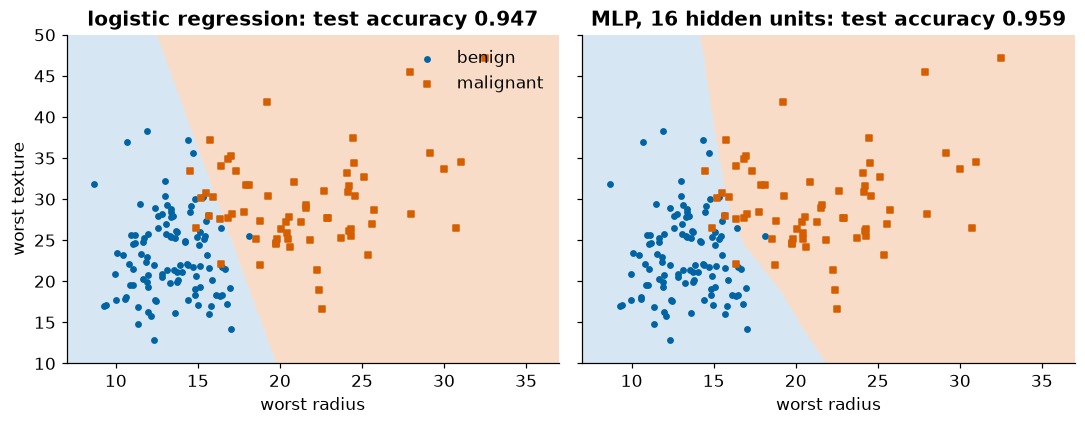

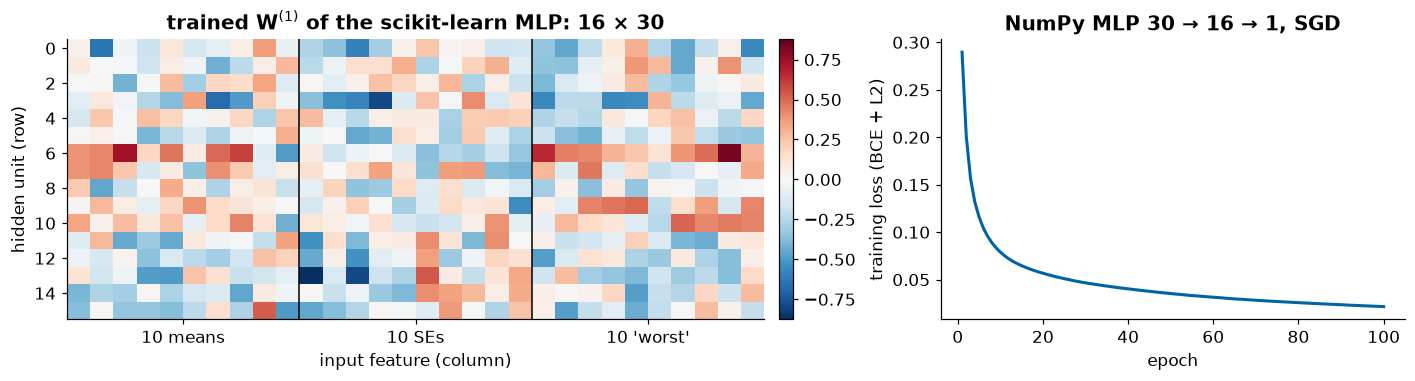

In [15]:
X2tr, X2te = Xtr[:, [j1, j2]], Xte[:, [j1, j2]]
lr2 = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)).fit(X2tr, ytr)
mlp2 = make_pipeline(StandardScaler(), MLPClassifier(hidden_layer_sizes=(16,), alpha=1e-2, max_iter=3000,
                                                     random_state=0)).fit(X2tr, ytr)
fig, axs = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
gx, gy = np.meshgrid(np.linspace(7, 37, 300), np.linspace(10, 50, 300))
for ax, m, name in zip(axs, [lr2, mlp2], ["logistic regression", "MLP, 16 hidden units"]):
    Z = m.predict(np.c_[gx.ravel(), gy.ravel()]).reshape(gx.shape)
    ax.contourf(gx, gy, Z, levels=[-.5, .5, 1.5], colors=["#D6E6F3", "#F9DCC8"])
    ax.scatter(X2te[yte == 0, 0], X2te[yte == 0, 1], s=12, color=C0, label="benign")
    ax.scatter(X2te[yte == 1, 0], X2te[yte == 1, 1], s=12, color=C1, marker="s", label="malignant")
    ax.set_title(f"{name}: test accuracy {m.score(X2te, yte):.3f}"); ax.set_xlabel("worst radius")
axs[0].set_ylabel("worst texture"); axs[0].legend(loc="upper right"); plt.tight_layout(); plt.show()

W1 = models["MLP, 30 → 16 → 1 (ReLU)"][-1].coefs_[0].T      # scikit-learn stores (d0, d1); transpose to (d1, d0)
ours = models["NumPy MLP, 30 → 16 → 1 (ours)"][-1]
fig, axs = plt.subplots(1, 2, figsize=(13, 3.6), gridspec_kw=dict(width_ratios=[1.6, 1]))
v = np.abs(W1).max()
im = axs[0].imshow(W1, cmap="RdBu_r", vmin=-v, vmax=v, aspect="auto")
for xv in (9.5, 19.5):
    axs[0].axvline(xv, color="k", lw=1)
axs[0].set_xticks([4.5, 14.5, 24.5], ["10 means", "10 SEs", "10 'worst'"])
axs[0].set_ylabel("hidden unit (row)"); axs[0].set_xlabel("input feature (column)")
axs[0].set_title(f"trained $\\mathbf{{W}}^{{(1)}}$ of the scikit-learn MLP: {W1.shape[0]} × {W1.shape[1]}")
fig.colorbar(im, ax=axs[0], fraction=0.04, pad=0.02)
axs[1].plot(np.arange(1, len(ours.hist_) + 1), ours.hist_, color=C0, lw=2)
axs[1].set_xlabel("epoch"); axs[1].set_ylabel("training loss (BCE + L2)"); axs[1].set_title("NumPy MLP 30 → 16 → 1, SGD")
plt.tight_layout(); plt.show()

## 11. Biological interpretation
On these 30 expert-designed nuclear features the MLP only **ties** with logistic regression: the malignant and benign biopsies
are already nearly linearly separable (larger, more irregular, more concave nuclei → malignant), so extra flexibility buys
nothing measurable. On two features the MLP bends its boundary where the classes overlap, but test accuracy barely moves —
a curved boundary is not necessarily a better one. With 171 test biopsies one error is 0.006, and the differences in the
table are one or two biopsies. Logistic regression keeps interpretable odds ratios (Lecture 5); the MLP's hidden units mix
many features (the heat map) and have no direct clinical reading. Nonlinear networks pay off with raw, high-dimensional
inputs — images and sequences (Lectures 9–13). Rule: start with the linear baseline and use a network only when it wins on
validation data by more than the noise. (A teaching example, not a diagnostic tool.)

In [16]:
print(f"total runtime {time.time() - T0:.0f} s")

total runtime 65 s


## 12. Try it yourself
1. **Swap tanh for ReLU (forward and backward); rerun the gradient check.** In §4 build `MLP(2, 8, 2, act="relu", ...)`
   (the `ACTS` dictionary holds both $g$ and $g'$). Does the check still pass? Retrain the width experiment in §6 with ReLU: how do the boundaries look?
2. **Train with squared error on sigmoid outputs; compare loss curves.** Subclass `MLP`: in `loss` use
   $\frac1n\sum_i\|\sigma(\mathbf z^{(2)}_i) - \mathbf y_i\|^2$ (replace `softmax` by `sigmoid` in `forward`) and change the first line of `backward` to
   $\boldsymbol\delta^{(2)} = 2(\hat{\mathbf y}-\mathbf y)\odot\hat{\mathbf y}\odot(1-\hat{\mathbf y})/n$. Rerun `grad_check`, then train with the §5
   settings and plot both loss curves (compare accuracy too — the two losses are on different scales). Why is squared error slower when the network is confidently wrong?
3. **Go deeper with sigmoid units; print gradient norms per layer.** Stack 10 sigmoid layers of width 64 (weights
   $\mathcal N(0, 1/64)$), push random inputs through, backpropagate a random upstream gradient with
   $\boldsymbol\delta^{(\ell)} = \mathbf G\odot g'(\mathbf z^{(\ell)})$, $\mathbf G \leftarrow \boldsymbol\delta^{(\ell)}\mathbf W^{(\ell)}$, and print
   $\|\partial\mathcal L/\partial\mathbf W^{(\ell)}\| = \|\boldsymbol\delta^{(\ell)\top}\mathbf H^{(\ell-1)}\|$. Which layer gets the smallest gradient? (Slide: layer 1's
   is about $3\times10^5$ times smaller than layer 10's.) Repeat with ReLU and weights $\mathcal N(0, 2/64)$.
4. On the biopsy data, repeat the comparison of logistic regression and the 16-unit MLP over 10 different `random_state`s of the
   train/test split. How often does the MLP win, lose, or tie on the test set? What does that say about the single split in §9?
5. *(CS284A)* Use `torch.func.jvp` and `torch.func.vjp` on the loss as a function of the flattened parameters of the §4 PyTorch
   network to compute one directional derivative and the full gradient. Which one gives the loss gradient in a single call, and
   how many JVP calls would forward mode need for all 513 parameters?